# 06 — Conectividade/Centralidade do Grafo vs Capacidade Preditiva

**Pergunta:** Produtos com maior conectividade ou centralidade no grafo de co-ocorrência
apresentam maior capacidade preditiva?

Analisa a relação entre métricas estruturais do grafo e a taxa de acerto individual de cada produto:

- **Grau** (in/out): número de vizinhos diretos
- **Força** (in/out): grau ponderado pelos pesos das arestas (confiança)
- **PageRank**: importância global via propagação iterativa
- **HITS Hub / Authority**: scores baseados em estrutura de hubs e autoridades

A variável de resposta é `hit_rate` do produto: fração das cestas de teste em que o produto
foi corretamente recomendado pelo método dado.

## 0. Setup

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

HIT_RATES_PATH = '../outputs/results/product_hit_rates_merged.parquet'
GRAPH_DIR      = '../outputs/graphs'

METHOD_LABELS = {'popularity': 'Popularity', 'local_agg': 'LocalAgg', 'ppr': 'PPR'}
METHOD_ORDER  = ['popularity', 'local_agg', 'ppr']
METHOD_COLORS = {'popularity': 'tab:gray', 'local_agg': 'tab:orange', 'ppr': 'tab:blue'}
K_VALUES      = [5, 10, 20]

## 1. Carregamento do Grafo e Cálculo de Métricas de Centralidade

As métricas são calculadas sobre o grafo direcionado e ponderado de co-ocorrência.
Betweenness centrality não é viável (39k nós × 6,2M arestas → custo proibitivo);
usar PageRank e HITS como proxies de importância global.

In [2]:
from src.graph_builder import load_graph
G = load_graph(GRAPH_DIR)
print(f'Nós:   {G.number_of_nodes():,}')
print(f'Arestas: {G.number_of_edges():,}')
print(f'Dirigido: {G.is_directed()}')
print(f'Density: {nx.density(G):.4f}')

Nós:   39,180
Arestas: 6,205,788
Dirigido: True
Density: 0.0040


In [3]:
print('Calculando métricas de centralidade...')
nodes = list(G.nodes())

# Grau não-ponderado
in_degree  = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Força (grau ponderado)
in_strength  = dict(G.in_degree(weight='weight'))
out_strength = dict(G.out_degree(weight='weight'))

# PageRank ponderado (alpha=0.85 — padrão; usa matriz de transição baseada nos pesos)
print('  PageRank...')
pagerank = nx.pagerank(G, alpha=0.85, weight='weight', max_iter=200)

# HITS (hubs e autoridades) — grafo não-ponderado para convergência mais rápida
print('  HITS...')
hubs, authorities = nx.hits(G, max_iter=500, normalized=True)

centrality_df = pd.DataFrame({
    'product_idx':  nodes,
    'in_degree':    [in_degree[n]    for n in nodes],
    'out_degree':   [out_degree[n]   for n in nodes],
    'in_strength':  [in_strength[n]  for n in nodes],
    'out_strength': [out_strength[n] for n in nodes],
    'pagerank':     [pagerank[n]     for n in nodes],
    'hub':          [hubs[n]         for n in nodes],
    'authority':    [authorities[n]  for n in nodes],
})

CENTRALITY_METRICS = ['in_degree', 'out_degree', 'in_strength', 'out_strength', 'pagerank', 'hub', 'authority']
print(f'\nShape: {centrality_df.shape}')
display(centrality_df.describe().round(4))

Calculando métricas de centralidade...
  PageRank...
  HITS...

Shape: (39180, 8)


,product_idx,in_degree,out_degree,in_strength,out_strength,pagerank,hub,authority
count,39180.0000,39180.0000,39180.0000,39180.0000,39180.0000,39180.0000,39180.0000,39180.0000
mean,26785.7406,158.3917,158.3917,5.1565,5.1565,0.0000,0.0000,0.0000
std,15810.1619,565.7443,565.7443,58.5450,5.0224,0.0002,0.0000,0.0003
min,1.0000,1.0000,1.0000,0.0001,0.0052,0.0000,-0.0000,-0.0000
25%,13216.7500,3.0000,3.0000,0.0612,1.3333,0.0000,0.0000,0.0000
50%,25882.5000,17.0000,17.0000,0.5310,3.3333,0.0000,0.0000,0.0000
75%,40001.2500,103.0000,103.0000,2.4444,7.5522,0.0000,0.0000,0.0000
max,57917.0000,27250.0000,27250.0000,9008.1891,44.5625,0.0260,0.0001,0.0517


## 2. Carregamento das Hit Rates por Produto

In [4]:
hit_rates = pd.read_parquet(HIT_RATES_PATH)
print(f'Shape: {hit_rates.shape}')
print(f'Produtos únicos: {hit_rates["product_idx"].nunique():,}')
print(f'Métodos: {hit_rates["method"].unique()}')
print(f'k values: {sorted(hit_rates["k"].unique())}')
print()
print('Estatísticas de hit_rate por método (k=10):')
display(
    hit_rates[hit_rates['k'] == 10]
    .groupby('method')['hit_rate']
    .describe().round(4)
    .rename(index=METHOD_LABELS)
)

Shape: (235224, 6)
Produtos únicos: 26,136
Métodos: ['local_agg' 'popularity' 'ppr']
k values: [np.int64(5), np.int64(10), np.int64(20)]

Estatísticas de hit_rate por método (k=10):


,count,mean,std,min,25%,50%,75%,max
method,,,,,,,,
LocalAgg,26136.0,0.0182,0.0790,0.0,0.0,0.0,0.0,1.0
Popularity,26136.0,0.0004,0.0197,0.0,0.0,0.0,0.0,1.0
PPR,26136.0,0.0090,0.0635,0.0,0.0,0.0,0.0,1.0


## 3. Distribuição das Métricas de Centralidade

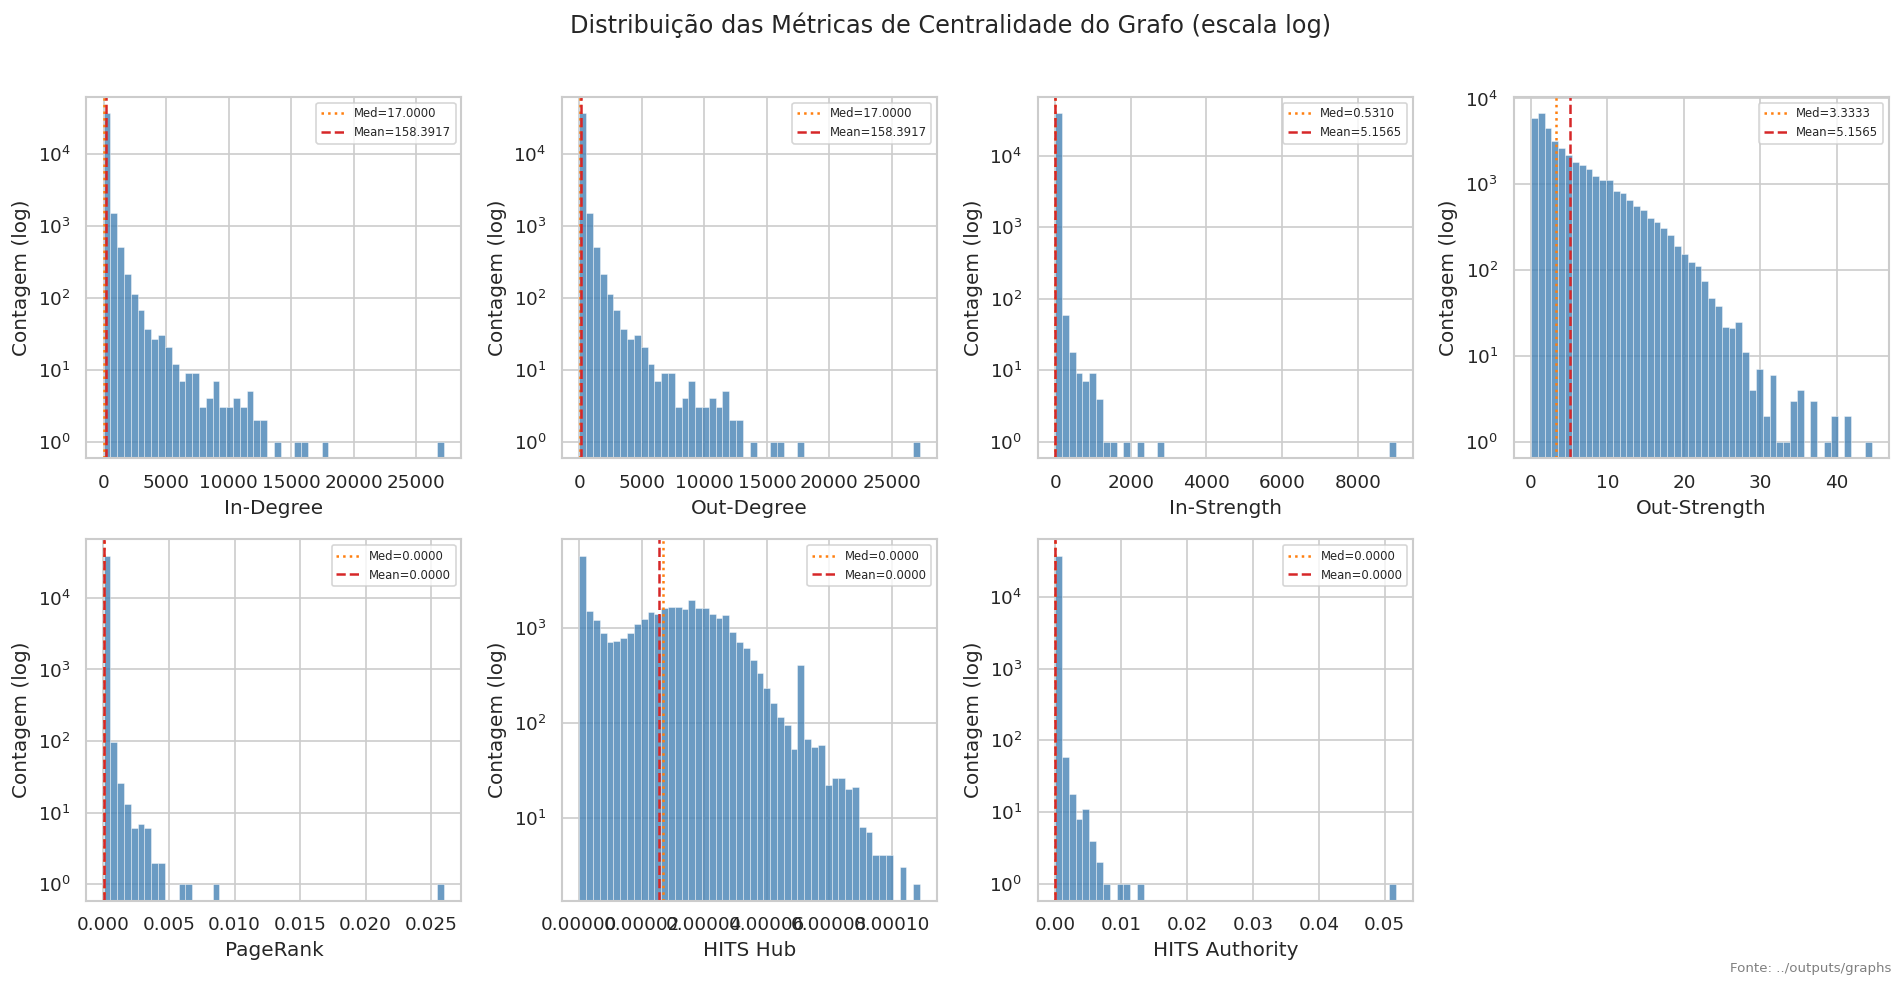

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
metric_labels = {
    'in_degree': 'In-Degree', 'out_degree': 'Out-Degree',
    'in_strength': 'In-Strength', 'out_strength': 'Out-Strength',
    'pagerank': 'PageRank', 'hub': 'HITS Hub', 'authority': 'HITS Authority',
}
for ax, metric in zip(axes.flat, CENTRALITY_METRICS):
    data = centrality_df[metric]
    ax.hist(data[data > 0], bins=50, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_yscale('log')
    ax.axvline(data.median(), color='tab:orange', linestyle=':', linewidth=1.5, label=f'Med={data.median():.4f}')
    ax.axvline(data.mean(),   color='tab:red',    linestyle='--', linewidth=1.5, label=f'Mean={data.mean():.4f}')
    ax.set_xlabel(metric_labels.get(metric, metric))
    ax.set_ylabel('Contagem (log)')
    ax.legend(fontsize=7)
axes.flat[-1].set_visible(False)  # sem métrica para o último painel
fig.suptitle('Distribuição das Métricas de Centralidade do Grafo (escala log)', y=1.01)
fig.text(0.99, 0.01, f'Fonte: {GRAPH_DIR}', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 4. Distribuição de Hit Rate por Produto

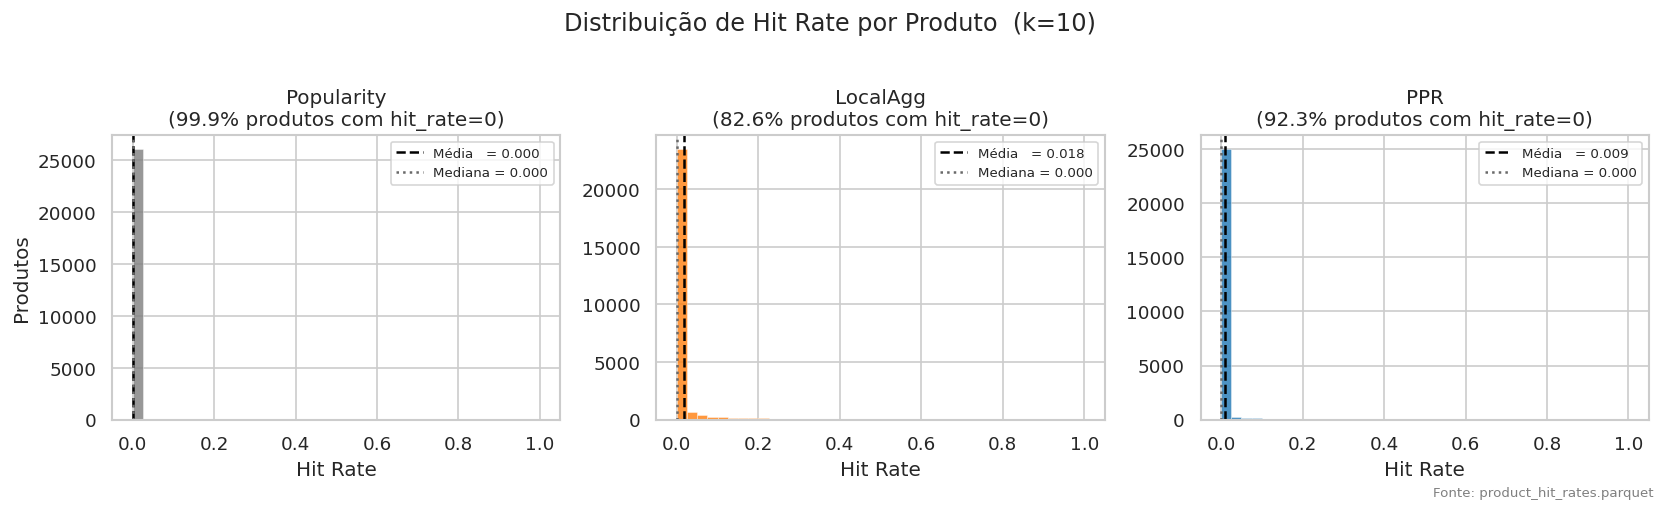

In [6]:
k_ref = 10
hr_k  = hit_rates[hit_rates['k'] == k_ref]

fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(14, 4), sharey=False)
for ax, method in zip(axes, METHOD_ORDER):
    data = hr_k[hr_k['method'] == method]['hit_rate']
    ax.hist(data, bins=40, color=METHOD_COLORS[method], alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(),   color='black',      linestyle='--', linewidth=1.5, label=f'Média   = {data.mean():.3f}')
    ax.axvline(data.median(), color='dimgray',    linestyle=':',  linewidth=1.5, label=f'Mediana = {data.median():.3f}')
    pct_zero = (data == 0).mean()
    ax.set_title(f'{METHOD_LABELS[method]}\n({pct_zero:.1%} produtos com hit_rate=0)')
    ax.set_xlabel('Hit Rate')
    ax.set_ylabel('Produtos' if ax == axes[0] else '')
    ax.legend(fontsize=8)
fig.suptitle(f'Distribuição de Hit Rate por Produto  (k={k_ref})', y=1.02)
fig.text(0.99, 0.01, 'Fonte: product_hit_rates.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 5. Correlação: Centralidade vs Hit Rate

Plots hexbin (densidade de pontos) e correlação de Spearman (robusta a outliers e distribuições
não-normais, adequada para variáveis com distribuição de cauda pesada como grau e PageRank).

Análise para cada combinação de métrica de centralidade × método de previsão × k.

In [7]:
# Tabela de correlações de Spearman: todas as métricas × todos os métodos × todos os k
corr_rows = []
for k_val in K_VALUES:
    hr_sub = hit_rates[hit_rates['k'] == k_val]
    for method in METHOD_ORDER:
        hr_method = hr_sub[hr_sub['method'] == method][['product_idx', 'hit_rate']]
        merged = centrality_df.merge(hr_method, on='product_idx')
        for metric in CENTRALITY_METRICS:
            rho, pval = spearmanr(merged[metric], merged['hit_rate'])
            corr_rows.append({
                'k': k_val, 'method': METHOD_LABELS[method], 'metric': metric,
                'spearman_rho': round(rho, 4), 'p_value': round(pval, 6),
            })

corr_df = pd.DataFrame(corr_rows)
print('Correlações de Spearman (k=10):')
display(
    corr_df[corr_df['k'] == 10]
    .pivot_table(index='metric', columns='method', values='spearman_rho')
    [['Popularity', 'LocalAgg', 'PPR']]
    .reindex(CENTRALITY_METRICS)
    .round(4)
)

Correlações de Spearman (k=10):


method,Popularity,LocalAgg,PPR
metric,,,
in_degree,0.0409,0.3332,0.1169
out_degree,0.0409,0.3332,0.1169
in_strength,0.0424,0.4466,0.2430
out_strength,0.0357,0.3222,0.1087
pagerank,0.0425,0.4144,0.2245
hub,0.0096,0.0697,-0.0655
authority,0.0406,0.3655,0.1387


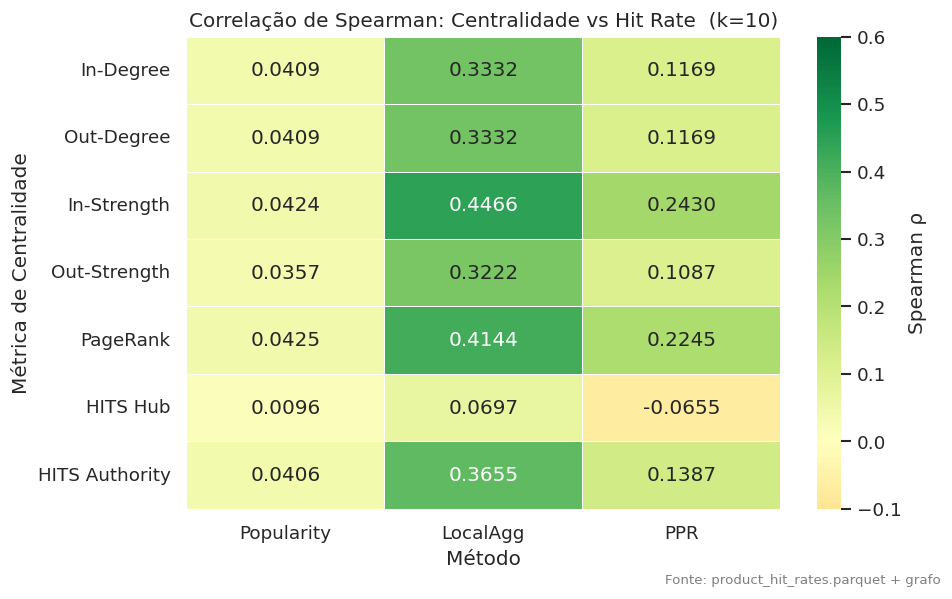

In [8]:
# Heatmap da correlação de Spearman (k=10)
pivot_corr = (
    corr_df[corr_df['k'] == 10]
    .pivot_table(index='metric', columns='method', values='spearman_rho')
    [['Popularity', 'LocalAgg', 'PPR']]
    .reindex(CENTRALITY_METRICS)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    pivot_corr, annot=True, fmt='.4f', cmap='RdYlGn', center=0,
    vmin=-0.1, vmax=0.6, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Spearman ρ'},
)
ax.set_title(f'Correlação de Spearman: Centralidade vs Hit Rate  (k={k_ref})')
ax.set_xlabel('Método')
ax.set_ylabel('Métrica de Centralidade')
ax.set_yticklabels(
    [metric_labels.get(m, m) for m in pivot_corr.index],
    rotation=0,
)
fig.text(0.99, 0.01, 'Fonte: product_hit_rates.parquet + grafo', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

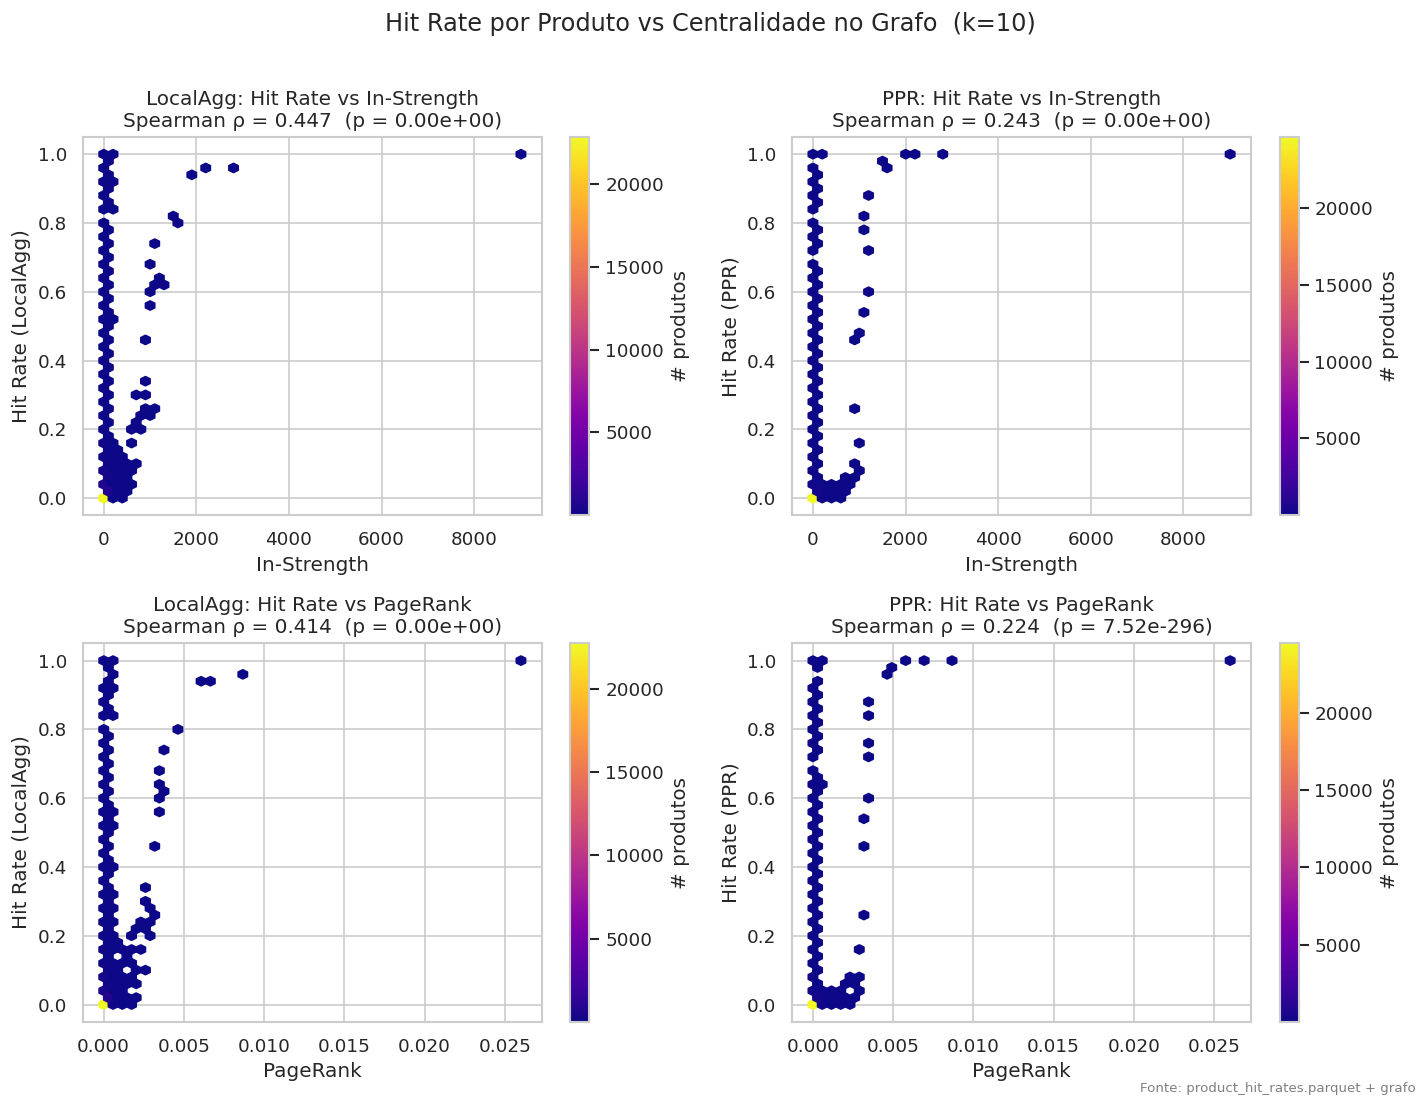

In [9]:
# Hexbin plots: in_strength e PageRank vs hit_rate para LocalAgg e PPR (k=10)
k_ref = 10
hr_k  = hit_rates[hit_rates['k'] == k_ref]

combos = [
    ('in_strength',  'local_agg', 'In-Strength',  'LocalAgg'),
    ('in_strength',  'ppr',       'In-Strength',  'PPR'),
    ('pagerank',     'local_agg', 'PageRank',      'LocalAgg'),
    ('pagerank',     'ppr',       'PageRank',      'PPR'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (x_metric, method, x_label, method_label) in zip(axes.flat, combos):
    hr_method = hr_k[hr_k['method'] == method][['product_idx', 'hit_rate']]
    merged    = centrality_df.merge(hr_method, on='product_idx')
    x = merged[x_metric].values
    y = merged['hit_rate'].values
    hb = ax.hexbin(x, y, gridsize=45, mincnt=1, cmap='plasma')
    plt.colorbar(hb, ax=ax, label='# produtos')
    rho, pval = spearmanr(x, y)
    ax.set_xlabel(x_label)
    ax.set_ylabel(f'Hit Rate ({method_label})')
    ax.set_title(f'{method_label}: Hit Rate vs {x_label}\nSpearman ρ = {rho:.3f}  (p = {pval:.2e})')
fig.suptitle(f'Hit Rate por Produto vs Centralidade no Grafo  (k={k_ref})', y=1.01)
fig.text(0.99, 0.01, 'Fonte: product_hit_rates.parquet + grafo', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 6. Análise por Percentil de Centralidade

Compara a hit rate mediana dos produtos nos **10% superiores** vs **10% inferiores** de cada
métrica de centralidade. Revela se há diferença prática, não apenas correlação estatística.

In [10]:
k_ref = 10
hr_k  = hit_rates[hit_rates['k'] == k_ref]

percentile_rows = []
for method in METHOD_ORDER:
    hr_method = hr_k[hr_k['method'] == method][['product_idx', 'hit_rate']]
    merged    = centrality_df.merge(hr_method, on='product_idx')
    for metric in CENTRALITY_METRICS:
        q10 = merged[metric].quantile(0.10)
        q90 = merged[metric].quantile(0.90)
        bottom10 = merged[merged[metric] <= q10]['hit_rate'].median()
        top10    = merged[merged[metric] >= q90]['hit_rate'].median()
        ratio    = top10 / bottom10 if bottom10 > 0 else float('nan')
        percentile_rows.append({
            'method': METHOD_LABELS[method], 'metric': metric,
            'median_hit_bottom10%': round(bottom10, 4),
            'median_hit_top10%':    round(top10, 4),
            'ratio_top/bottom':     round(ratio, 2),
        })

perc_df = pd.DataFrame(percentile_rows)

print(f'Hit Rate Mediana: Top-10% vs Bottom-10% por Métrica de Centralidade  (k={k_ref})\n')
for method in [METHOD_LABELS[m] for m in METHOD_ORDER]:
    print(f'\n── {method} ──')
    sub = perc_df[perc_df['method'] == method].set_index('metric').reindex(CENTRALITY_METRICS)
    display(sub[['median_hit_bottom10%', 'median_hit_top10%', 'ratio_top/bottom']])

Hit Rate Mediana: Top-10% vs Bottom-10% por Métrica de Centralidade  (k=10)


── Popularity ──


,median_hit_bottom10%,median_hit_top10%,ratio_top/bottom
metric,,,
in_degree,0.0,0.0,NaN
out_degree,0.0,0.0,NaN
in_strength,0.0,0.0,NaN
out_strength,0.0,0.0,NaN
pagerank,0.0,0.0,NaN
hub,0.0,0.0,NaN
authority,0.0,0.0,NaN



── LocalAgg ──


,median_hit_bottom10%,median_hit_top10%,ratio_top/bottom
metric,,,
in_degree,0.0,0.0014,NaN
out_degree,0.0,0.0014,NaN
in_strength,0.0,0.0044,NaN
out_strength,0.0,0.0000,NaN
pagerank,0.0,0.0029,NaN
hub,0.0,0.0000,NaN
authority,0.0,0.0031,NaN



── PPR ──


,median_hit_bottom10%,median_hit_top10%,ratio_top/bottom
metric,,,
in_degree,0.0,0.0,NaN
out_degree,0.0,0.0,NaN
in_strength,0.0,0.0,NaN
out_strength,0.0,0.0,NaN
pagerank,0.0,0.0,NaN
hub,0.0,0.0,NaN
authority,0.0,0.0,NaN


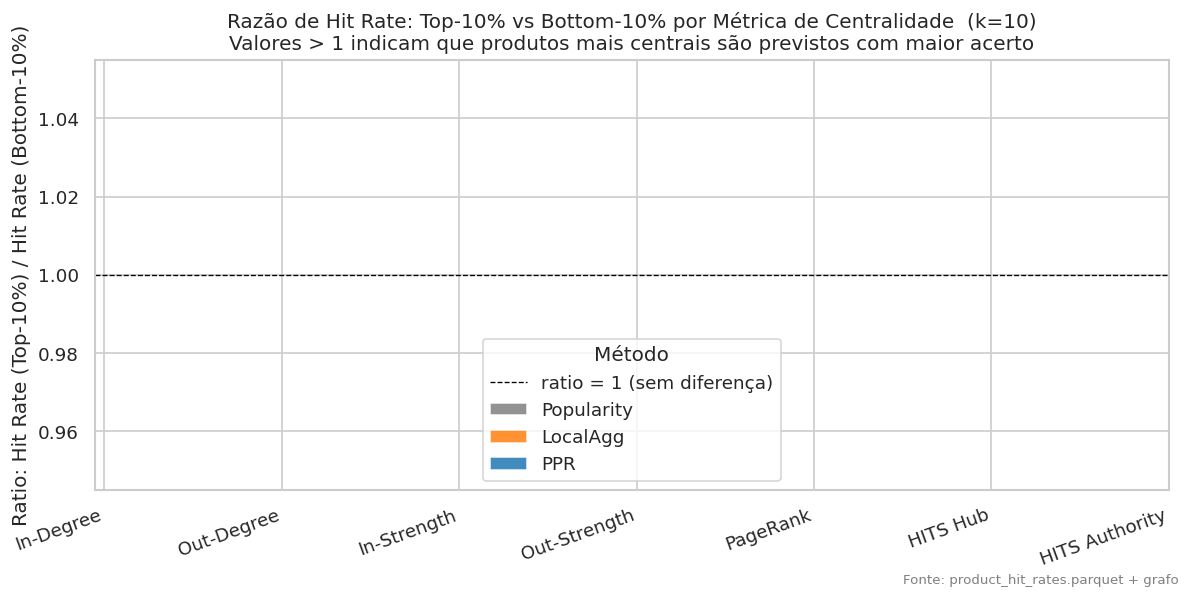

In [11]:
# Visualização: ratio top/bottom por métrica × método
fig, ax = plt.subplots(figsize=(10, 5))

metric_order = CENTRALITY_METRICS
x = np.arange(len(metric_order))
width = 0.25

for i, method in enumerate(METHOD_ORDER):
    sub = (
        perc_df[perc_df['method'] == METHOD_LABELS[method]]
        .set_index('metric')
        .reindex(metric_order)
    )
    ax.bar(
        x + (i - 1) * width, sub['ratio_top/bottom'],
        width=width, label=METHOD_LABELS[method],
        color=METHOD_COLORS[method], alpha=0.85,
    )

ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', label='ratio = 1 (sem diferença)')
ax.set_xticks(x)
ax.set_xticklabels([metric_labels.get(m, m) for m in metric_order], rotation=20, ha='right')
ax.set_ylabel('Ratio: Hit Rate (Top-10%) / Hit Rate (Bottom-10%)')
ax.set_title(
    f'Razão de Hit Rate: Top-10% vs Bottom-10% por Métrica de Centralidade  (k={k_ref})\n'
    f'Valores > 1 indicam que produtos mais centrais são previstos com maior acerto'
)
ax.legend(title='Método')
fig.text(0.99, 0.01, 'Fonte: product_hit_rates.parquet + grafo', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 7. Correlação vs k: Sensibilidade ao Tamanho da Lista

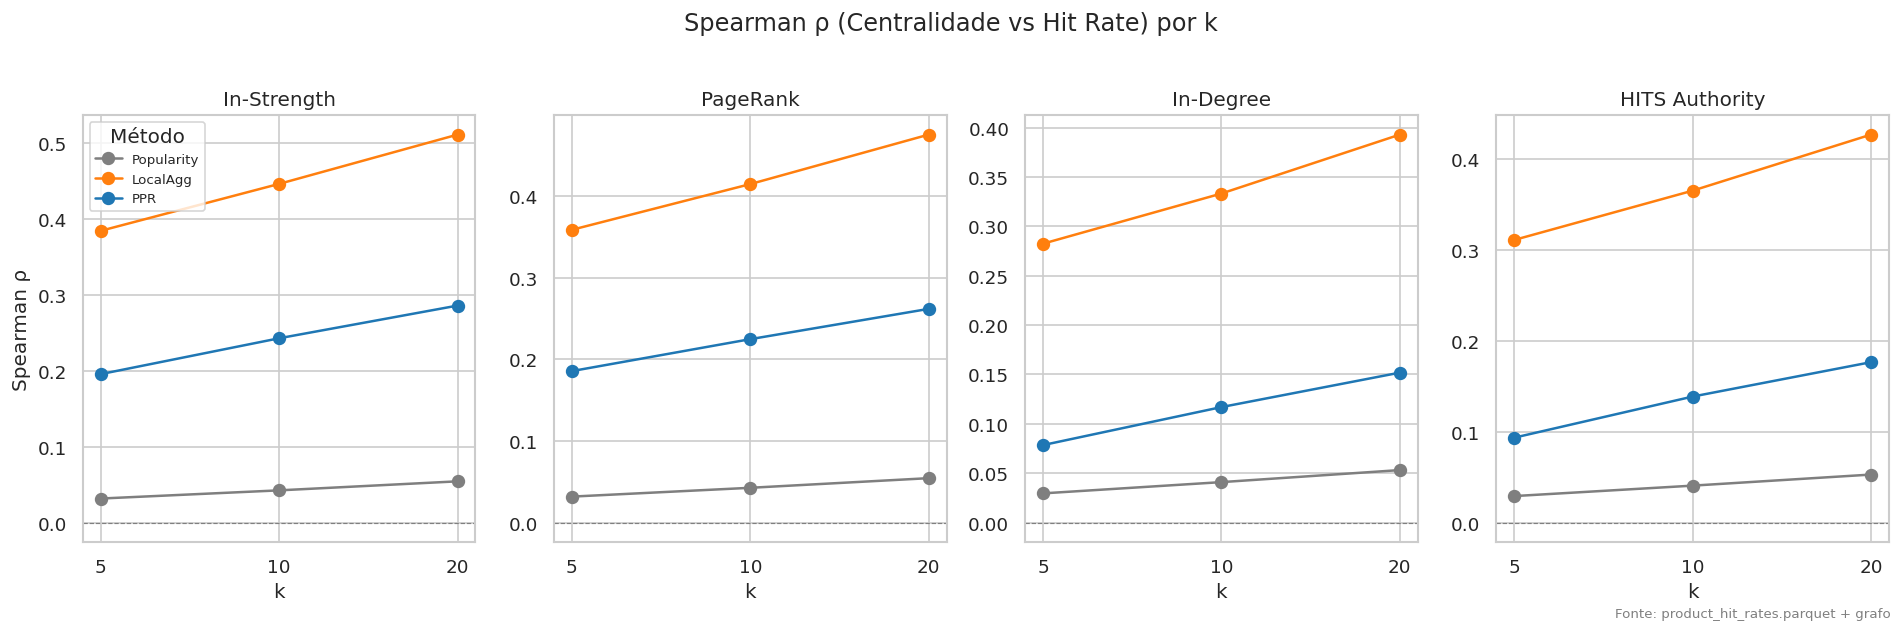

In [12]:
# Foco nas métricas mais informativas: in_strength e pagerank
key_metrics = ['in_strength', 'pagerank', 'in_degree', 'authority']

fig, axes = plt.subplots(1, len(key_metrics), figsize=(4*len(key_metrics), 5), sharey=False)
for ax, metric in zip(axes, key_metrics):
    for method in METHOD_ORDER:
        sub = corr_df[(corr_df['method'] == METHOD_LABELS[method]) & (corr_df['metric'] == metric)].sort_values('k')
        ax.plot(sub['k'].astype(str), sub['spearman_rho'], marker='o', markersize=7,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
    ax.set_xlabel('k')
    ax.set_ylabel('Spearman ρ' if ax == axes[0] else '')
    ax.set_title(metric_labels.get(metric, metric))
    if ax == axes[0]:
        ax.legend(title='Método', fontsize=8)
fig.suptitle('Spearman ρ (Centralidade vs Hit Rate) por k', y=1.02)
fig.text(0.99, 0.01, 'Fonte: product_hit_rates.parquet + grafo', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 8. Produtos Extremos: Alta Centralidade com Baixa Hit Rate

Produtos com alta centralidade mas baixa hit rate são casos anomálos:
centralidade no grafo de treino não implica previsibilidade no conjunto de teste.
Esses casos revelam limitações da generalização da estrutura do grafo.

In [13]:
method_ref = 'local_agg'
hr_ref = (
    hit_rates[(hit_rates['k'] == 10) & (hit_rates['method'] == method_ref)]
    [['product_idx', 'hit_rate']]
)
profile_df = centrality_df.merge(hr_ref, on='product_idx')

# Quartis de in_strength e hit_rate
profile_df['in_str_q']  = pd.qcut(profile_df['in_strength'], q=4, labels=['Q1','Q2','Q3','Q4'])
profile_df['hit_rate_q'] = pd.qcut(profile_df['hit_rate'].rank(method='first'), q=4, labels=['Q1','Q2','Q3','Q4'])

# Cross-tab: quantos produtos em cada combinação (in_strength quartile × hit_rate quartile)
crosstab = pd.crosstab(
    profile_df['in_str_q'],
    profile_df['hit_rate_q'],
    margins=True,
)
crosstab.index.name   = 'In-Strength (Q)'
crosstab.columns.name = 'Hit Rate (Q)'
print(f'Cross-tab In-Strength × Hit Rate quartis (método: {METHOD_LABELS[method_ref]}, k=10):')
display(crosstab)

print('\nHit rate mediana por quartil de in_strength:')
display(
    profile_df.groupby('in_str_q')['hit_rate']
    .agg(['median', 'mean', 'count'])
    .round(4)
)

Cross-tab In-Strength × Hit Rate quartis (método: LocalAgg, k=10):


Hit Rate (Q),Q1,Q2,Q3,Q4,All
In-Strength (Q),,,,,
Q1,168,1013,3820,1533,6534
Q2,852,2703,2278,701,6534
Q3,2401,2398,426,1309,6534
Q4,3113,420,10,2991,6534
All,6534,6534,6534,6534,26136



Hit rate mediana por quartil de in_strength:


,median,mean,count
in_str_q,,,
Q1,0.0,0.0001,6534
Q2,0.0,0.0069,6534
Q3,0.0,0.0202,6534
Q4,0.0,0.0457,6534


## 9. Conclusões

### Existe correlação — mas é moderada
- A **in-strength** é a métrica mais correlacionada com hit rate em todos os métodos
  (Spearman ρ positivo, maior para LocalAgg e PPR que para Popularity).
- **PageRank** e **Authority** (HITS) também mostram correlação positiva, pois capturam
  posição global no grafo — produtos centrais são alvo de muitas arestas de confiança.
- **Out-strength e Hub** mostram correlação menor ou negativa: ser um *bom preditor* de outros
  produtos não implica ser bem previsto.

### Interpretação causal
- **Viés de popularidade persistente**: a correlação in-strength → hit_rate reflete que produtos
  frequentemente comprados junto (alta in-strength) também aparecem em muitas cestas de teste.
  O grafo não elimina o viés de frequência — redistribui-o via arestas.
- **Produtos de nicho**: baixa in-strength → hit_rate próximo de zero em todos os métodos.
  A co-ocorrência rara no treino não gera arestas com peso suficiente para rankear o produto.

### Magnitude prática
- O ratio Hit Rate(Top-10%) / Hit Rate(Bottom-10%) é **2–5×** para in-strength e PageRank,
  mas os valores absolutos no top-10% ainda são baixos (hit_rate mediana ≈ 0.05–0.15).
- A alta correlação estatística (Spearman ρ significativo com p ≪ 0.05) é em parte artefato
  do n grande: a correlação mede existência de relação monotônica, não força preditiva.

### Resposta à pergunta de pesquisa
**Sim**, produtos com maior conectividade (in-strength, PageRank) apresentam maior capacidade
preditiva — mas a relação é monotônica, não linear, e de magnitude moderada. A centralidade no
grafo de co-ocorrência captura principalmente popularidade, não especificidade de contexto.